## Data Science Project 2: Sentiment Analysis with Natural Language Processing 

#### By Fionn McGlacken, ID: 19388186, June 8th, 2021.

This project is completed to earn 5 credits for the NUI Galway DSC2100 Data Science Project 2 module under the supervision of Dr. Nick Tosh. It has two parts:

- Part 1: An Introduction to Natural Language Processing.
- Part 2: Sentiment Analysis of Cryptocurrency News Headlines Before and After the May 2021 'Crypto Crash'.

In [916]:
#import all necessary modules

import nltk
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
import re
from nltk.tokenize import regexp_tokenize
from nltk.tokenize import TweetTokenizer
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy
import scipy
import gensim
from gensim.corpora.dictionary import Dictionary
from collections import defaultdict
import itertools
from gensim.models.tfidfmodel import TfidfModel
import urllib
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\fionn\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexico

True

## Part 1

### An Introduction to Natural Language Processing

Natural Language Processing (NLP) refers to the processing and analysis of natural language data like speech and text. It is used in tasks involving speech recognition, natural language understanding, translation and natural language generation. 

A Datacamp module, 'Introduction to Natural Language Processing in Python', was completed to learn NLP coding concepts and skills. Material from this module will be discussed.

#### Regular Expressions

Regular expressions (regex) are strings with special syntax that allow us to match patterns in other strings. They are part of the re library.

Different regex strings are used to match specific patterns. Here are some common examples:

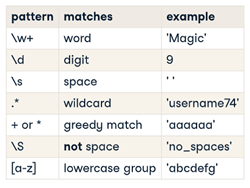

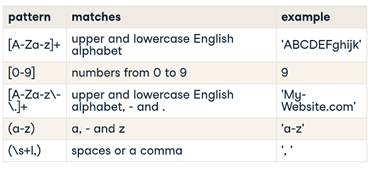

Different operations are used to match patterns in different ways.

In [917]:
my_string = 'Let''s do data science! 1, 2, 3... here we go.'

#in regex operations, the 1st argument is the pattern and the 2nd argument is the string

#matches an entire string or substring based on a pattern (e.g. words)
match = re.match('\w+', my_string)

#finds all patterns in a string (e.g. words)
findall = re.findall('\w+', my_string)

#splits a string on a regex (e.g. sentence endings)
split = re.split(r'[!]', my_string)

#searches for a pattern (e.g. digits)
search = re.search('\d', my_string)

print("Match:", match)
print("Findall:", findall)
print("Split:", split)
print("Search:", search)

Match: <re.Match object; span=(0, 4), match='Lets'>
Findall: ['Lets', 'do', 'data', 'science', '1', '2', '3', 'here', 'we', 'go']
Split: ['Lets do data science', ' 1, 2, 3... here we go.']
Search: <re.Match object; span=(22, 23), match='1'>


In this output, we can see the result of different operations. Observe the subtle distinction between 'Match' and 'Search'. Match will match a string from the beginning until it cannot match any longer. Search will go through the entire string to look for match options. 

#### Tokenisation

Tokenisation is the process of turning a string(s) into smaller chunks called tokens. Typically, this is used to break out words or sentences and separate punctuation or parts of a string. Tokenisation can be done through the natural language toolkit (nltk) module.

In [918]:
my_string2 = "This is a sentence. So is this! This too! This is the last sentence."

#tokenises string into sentences
sentences = sent_tokenize(my_string)

#tokenises string into words and creates a set
unique_tokens = set(word_tokenize(my_string2))

print("Sentences:", sentences)
print("Words:", unique_tokens)

Sentences: ['Lets do data science!', '1, 2, 3... here we go.']
Words: {'.', 'This', 'is', 'So', 'this', 'sentence', '!', 'a', 'the', 'last', 'too'}


Tokenisation can also be used to separate mentions and hashtags in tweets.

In [919]:
tweets = ['This is a great #nlp exercise! #python',
 '#NLP is super fun! <3 #learning',
 'Thanks @datacamp :) #nlp #python']

#specifies pattern as words beginning with '@' or '#'
pattern = r"([@#]\w+)"
mentions_hashtags = regexp_tokenize(tweets[-1], pattern)

print(mentions_hashtags, '\n')

['@datacamp', '#nlp', '#python'] 



### Topic Identification

A central task of NLP is determining the most important aspects of a text. These aspects include sentiment, dialect and topic. Topic identification can be achieved through bag-of-words models.

#### Bag-of-words

Bag-of-words (BOW) models operate under the assumption that the more frequent a word is, the more important it is to the text. BOW models can be created using tokenisation and the Counter module. 

In [920]:
#create tokens
tokens = word_tokenize(my_string2)
#preprocess tokens by decapitalising
lower_tokens = [t.lower() for t in tokens]
#count tokens
bow = Counter(lower_tokens)
#print the most common tokens
print(bow.most_common(5))

[('this', 4), ('is', 3), ('sentence', 2), ('.', 2), ('!', 2)]


As we can see, the most common words in our text are 'this' and 'is'. However, these words hardly seem to be the most important! This shows the need for preprocessing.

#### Preprocessing

Preprocessing refers to the preparation of data for processing to save space and time. The most common words in the text above are so common in the English language that they appear in most strings. They are known as stop words and don't provide much useful information. By preprocessing, we can remove stop words from the text. 

Preprocessing includes:
- Lemmatization/stemming: shortening words to their root 'stems'.
- Lowercasing words
- Removing stop words, punctuation or unwanted tokens

In [921]:
#removes stop words
no_stops = [token for token in lower_tokens if token not in stopwords.words('english')]

#lemmatizes words
wordnet_lemmatizer = WordNetLemmatizer()
lemmatized = [wordnet_lemmatizer.lemmatize(token) for token in no_stops]

puncs = '.,?!'
#removes puncuation
no_puncs = [t for t in lemmatized if t not in puncs]

bow = Counter(no_puncs)
print(bow.most_common(2))

[('sentence', 2), ('last', 1)]


As we have removed the stop words, the two most frequent words are 'sentence' and 'last'. These give a better idea about the content of the text! Preprocessing will be used throughout this project.

#### Gensim

As we dive deeper into NLP, it is useful to use libraries to perform some of our tasks. Gensim is a popular open source NLP library that uses top academic models to perform complex tasks. These tasks include building corpora and document/word vectors.

- A corpus (plural: corpora) is a set of texts used to perform NLP tasks.
- Word vectors are a multi-dimensional mathematical representations of words. They are arrays with sparse features (lots of 0s and some 1s) that give insight into relationships between words. They are created by deep learning algorithms that look at how words are used in large corpora. 

Below, preprocessed articles from datacamp are used to demonstrate creating a BOW model with Gensim.

In [922]:
#preprocessed articles from wikipedia via datacamp
#lowercased, tokenized, and stop words and punctuation removed
article1 = ['uses','file','operating','system','placement','software','.svg|thumb|upright|a','diagram','showing','user','computing','|user','interacts','application','software','typical','desktop','computer.the','application','software','layer','interfaces','operating','system','turn','communicates','personal','computer','hardware|hardware','arrows','indicate','information','flow',"''",'computer','software',"''",'simply',"''",'software',"''",'part','computer','system','consists','data','computing','|data','computer','instructions','contrast','computer','hardware|physical','hardware','system','built','computer','science','software','engineering','computer','software','information','processed','computer','systems','computer','program|programs','data','computer','software','includes','computer','programs','library','computing','|libraries','related','non-executable','data','computing','|data','software','documentation|online','documentation','digital','media','computer','hardware','software','require','neither','realistically','used','lowest','level','executable','code','consists','machine','code|machine','language','instructions','specific','individual','microprocessor|processor—typically','central','processing','unit','cpu','machine','language','consists','groups','binary','numbers|binary','values','signifying','processor','instructions','change','state','computer','preceding','state','example','instruction','may','change','value','stored','particular','storage','location','computer—an','effect','directly','observable','user','instruction','may','also','indirectly','cause','something','appear','display','computer','system—a','state','change','visible','user','processor','carries','instructions','order','provided','unless','instructed','branch','instruction|',"''",'jump',"''",'different','instruction','interrupted','multi-core','processors','dominant','core','run','instructions','order','however','application','software','runs','one','core','default','software','made','run','many','majority','software','written','high-level','programming','languages','easier','efficient','programmers','meaning','closer','natural','language','cite','web|title=compiler','construction|url=http','//www.cs.uu.nl/education/vak.php','vak=infomcco','high-level','languages','translated','machine','language','using','compiler','interpreter','computing','|interpreter','combination','two','software','may','also','written','low-level','assembly','language','essentially','vaguely','mnemonic','representation','machine','language','using','natural','language','alphabet','translated','machine','language','using','assembly','language|assembler','history','main','article|history','software','outline','algorithm','would','first','piece','software','written','ada','lovelace','19th','century','planned','analytical','engine','however','neither','analytical','engine','software','ever','created','first','theory','software—prior','creation','computers','know','today—was','proposed','alan','turing','1935','essay',"''computable",'numbers','application','entscheidungsproblem',"''",'decision','problem','eventually','led','creation','twin','academic','fields','computer','science','software','engineering','study','software','creation','computer','science','theoretical','turing',"'s",'essay','example','computer','science','software','engineering','focuses','practical','concerns','however','prior','1946','software','understand','it—programs','stored','memory','stored-program','digital','computers—did','yet','exist','first','electronic','computing','devices','instead','rewired','order','``','reprogram',"''",'types','software','see','also|list','software','categories','virtually','computer','platforms','software','grouped','broad','categories','=purpose','domain','use=','based','goal','computer','software','divided',"''application",'software',"''",'software','uses','computer','system','perform','special','functions','provide','video','game|entertainment','functions','beyond','basic','operation','computer','many','different','types','application','software','range','tasks','performed','modern','computer','large—see','list','software',"''system",'software',"''",'software','directly','operates','computer','hardware','provide','basic','functionality','needed','users','software','provide','platform','running','application','software','cite','web|title=system','software|url=http','//home.olemiss.edu/~misbook/sfsysfm.htm|archive-url=https','//web.archive.org/web/20010530092843/http','//home.olemiss.edu:80/~misbook/sfsysfm.htm|dead-url=yes|archive-date=2001-05-30|publisher=the','university','mississippi','system','software','includes',"''operating",'systems',"''",'essential','collections','software','manage','resources','provides','common','services','software','runs','``','top',"''",'supervisory','programs','boot','loaders','shell','computing','|shells','window','systems','core','parts','operating','systems','practice','operating','system','comes','bundled','additional','software','including','application','software','user','potentially','work','computer','operating','system',"''device",'drivers',"''",'operate','control','particular','type','device','attached','computer','device','needs','least','one','corresponding','device','driver','computer','typically','minimum','least','one','input','device','least','one','output','device','computer','typically','needs','one','device','driver',"''software",'utility|utilities',"''",'computer','programs','designed','assist','users','maintenance','care','computers',"''malicious",'software',"''","''malware","''",'software','developed','harm','disrupt','computers','malware','undesirable','malware','closely','associated','computer-related','crimes','though','malicious','programs','may','designed','practical','jokes','=nature','domain','execution=','desktop','applications','web','browsers','microsoft','office','well','smartphone','tablet','computer|tablet','applications','called','``','mobile','app|apps',"''",'push','parts','software','industry','merge','desktop','applications','mobile','apps','extent','windows','8','later','ubuntu','touch','tried','allow','style','application','user','interface','used','desktops','laptops','mobiles','javascript','scripts','pieces','software','traditionally','embedded','web','pages','run','directly','inside','web','browser','web','page','loaded','without','need','web','browser','plugin','software','written','programming','languages','also','run','within','web','browser','software','either','translated','javascript','web','browser','plugin','supports','language','installed','common','example','latter','actionscript','scripts','supported','adobe','flash','plugin','server','software','including','web','applications','usually','run','web','server','output','dynamically','generated','web','pages','web','browsers','using','e.g','php','java','programming','language','|java','asp.net','even','node.js|javascript','runs','server','modern','times','commonly','include','javascript','run','web','browser','well','case','typically','run','partly','server','partly','web','browser','plug-in','computing','|plugins','extensions','software','extends','modifies','functionality','another','piece','software','require','software','used','order','function','embedded','software','resides','firmware','within','embedded','systems','devices','dedicated','single','use','uses','cars','televisions','although','embedded','devices','wireless','chipsets',"''themselves","''",'part','ordinary','non-embedded','computer','system','pc','smartphone','cite','web|title=embedded','software—technologies','trends|url=http','//www.computer.org/csdl/mags/so/2009/03/mso2009030014.html|publisher=ieee','computer','society|date=may–june','2009|accessdate=6','november','2013','embedded','system','context','sometimes','clear','distinction','system','software','application','software','however','embedded','systems','run','embedded','operating','systems','systems','retain','distinction','system','software','application','software','although','typically','one','fixed','application','always','run','microcode','special','relatively','obscure','type','embedded','software','tells','processor',"''itself","''",'execute','machine','code','actually','lower','level','machine','code','typically','proprietary','processor','manufacturer','necessary','correctional','microcode','software','updates','supplied','users','much','cheaper','shipping','replacement','processor','hardware','thus','ordinary','programmer','would','expect','ever','deal','=programming','tools=','main','article|programming','tool','programming','tools','also','software','form','programs','applications','software','developers','also','known',"''programmers",'coders','hackers',"''","''software",'engineers',"''",'use','create','debugging|debug','software','maintenance|maintain','i.e','improve','fix','otherwise','technical','support|support','software','software','written','one','programming','languages','many','programming','languages','existence','least','one','implementation','consists','set','programming','tools','tools','may','relatively','self-contained','programs','compilers','debuggers','interpreter','computing','|interpreters','linker','computing','|linkers','text','editors','combined','together','accomplish','task','may','form','integrated','development','environment','ide','combines','much','functionality','self-contained','tools','ides','may','either','invoking','relevant','individual','tools','re-implementing','functionality','new','way','ide','make','easier','specific','tasks','searching','files','particular','project','many','programming','language','implementations','provide','option','using','individual','tools','ide','software','topics','=architecture=','see','also|software','architecture','users','often','see','things','differently','programmers','people','use','modern','general','purpose','computers','opposed','embedded','systems','analog','computers','supercomputers','usually','see','three']
article2 = ["''",'debugging',"''",'process','finding','resolving','defects','prevent','correct','operation','computer','software','system','numerous','books','written','debugging','see','reading|further','reading','involves','numerous','aspects','including','interactive','debugging','control','flow','integration','testing','logfile|log','files','monitoring','application','monitoring|application','system','monitoring|system','memory','dumps','profiling','computer','programming','|profiling','statistical','process','control','special','design','tactics','improve','detection','simplifying','changes','origin','computer','log','entry','mark','nbsp','ii','moth','taped','page','terms','``','bug',"''",'``','debugging',"''",'popularly','attributed','admiral','grace','hopper','1940s','http','//foldoc.org/grace+hopper','grace','hopper','foldoc','working','harvard','mark','ii|mark','ii','computer','harvard','university','associates','discovered','moth','stuck','relay','thereby','impeding','operation','whereupon','remarked','``','debugging',"''",'system','however','term','``','bug',"''",'meaning','technical','error','dates','back','least','1878','thomas','edison','see','software','bug','full','discussion','``','debugging',"''",'seems','used','term','aeronautics','entering','world','computers','indeed','interview','grace','hopper','remarked','coining','term','citation','needed|date=july','2015','moth','fit','already','existing','terminology','saved','letter','j.','robert','oppenheimer','director','wwii','atomic','bomb','``','manhattan',"''",'project','los','alamos','nm','used','term','letter','dr.','ernest','lawrence','uc','berkeley','dated','october','27','1944','http','//bancroft.berkeley.edu/exhibits/physics/images/bigscience25.jpg','regarding','recruitment','additional','technical','staff','oxford','english','dictionary','entry','``','debug',"''",'quotes','term','``','debugging',"''",'used','reference','airplane','engine','testing','1945','article','journal','royal','aeronautical','society','article','``','airforce',"''",'june','1945','p.','nbsp','50','also','refers','debugging','time','aircraft','cameras','hopper',"'s",'computer','bug|bug','found','september','9','1947.','term','adopted','computer','programmers','early','1950s','seminal','article','gills','gill','http','//www.jstor.org/stable/98663','diagnosis','mistakes','programmes','edsac','proceedings','royal','society','london','series','mathematical','physical','sciences','vol','206','1087','may','22','1951','pp','538-554','1951','earliest','in-depth','discussion','programming','errors','use','term','``','bug',"''",'``','debugging',"''",'association','computing','machinery|acm',"'s",'digital','library','term','``','debugging',"''",'first','used','three','papers','1952','acm','national','meetings.robert','v.','d.','campbell','http','//portal.acm.org/citation.cfm','id=609784.609786','evolution','automatic','computation','proceedings','1952','acm','national','meeting','pittsburgh','p','29-32','1952.alex','orden','http','//portal.acm.org/citation.cfm','id=609784.609793','solution','systems','linear','inequalities','digital','computer','proceedings','1952','acm','national','meeting','pittsburgh','p.','91-95','1952.howard','b.','demuth','john','b.','jackson','edmund','klein','n.','metropolis','walter','orvedahl','james','h.','richardson','http','//portal.acm.org/citation.cfm','id=800259.808982','maniac','proceedings','1952','acm','national','meeting','toronto','p.','13-16','two','three','use','term','quotation','marks','1963','``','debugging',"''",'common','enough','term','mentioned','passing','without','explanation','page','1','compatible','time-sharing','system|ctss','manual','http','//www.bitsavers.org/pdf/mit/ctss/ctss_programmersguide.pdf','compatible','time-sharing','system','m.i.t','press','1963','kidwell',"'s",'article',"''stalking",'elusive','computer','bug',"''",'peggy','aldrich','kidwell','http','//ieeexplore.ieee.org/xpl/freeabs_all.jsp','tp=','arnumber=728224','isnumber=15706','stalking','elusive','computer','bug','ieee','annals','history','computing','1998.','discusses','etymology','``','bug',"''",'``','debug',"''",'greater','detail','scope','software','electronic','systems','become','generally','complex','various','common','debugging','techniques','expanded','methods','detect','anomalies','assess','impact','schedule','software','patches','full','updates','system','words','``','anomaly',"''",'``','discrepancy',"''",'used','neutral','terms','avoid','words','``','error',"''",'``','defect',"''",'``','bug',"''",'might','implication','so-called',"''errors","''","''defects","''","''bugs","''",'must','fixed','costs','instead','impact','assessment','made','determine','changes','remove',"''anomaly","''","''discrepancy","''",'would','cost-effective','system','perhaps','scheduled','new','release','might','render','change','unnecessary','issues','life-critical','mission-critical','system','also','important','avoid','situation','change','might','upsetting','users','long-term','living','known','problem','``','cure','would','worse','disease',"''",'basing','decisions','acceptability','anomalies','avoid','culture','``','zero-defects',"''",'mandate','people','might','tempted','deny','existence','problems','result','would','appear','zero',"''defects","''",'considering','collateral','issues','cost-versus-benefit','impact','assessment','broader','debugging','techniques','expand','determine','frequency','anomalies','often','``','bugs',"''",'occur','help','assess','impact','overall','system','tools','debugging','video','game','consoles','usually','done','special','hardware','xbox','console','|xbox','debug','unit','intended','developers','debugging','ranges','complexity','fixing','simple','errors','performing','lengthy','tiresome','tasks','data','collection','analysis','scheduling','updates','debugging','skill','programmer','major','factor','ability','debug','problem','difficulty','software','debugging','varies','greatly','complexity','system','also','depends','extent','programming','language','used','available','tools',"''debuggers","''",'debuggers','software','tools','enable','programmer','monitor','execution','computers','|execution','program','stop','restart','set','breakpoints','change','values','memory','term',"''debugger","''",'also','refer','person','debugging','generally','high-level','programming','languages','java','programming','language','|java','make','debugging','easier','features','exception','handling','make','real','sources','erratic','behaviour','easier','spot','programming','languages','c','programming','language','|c','assembly','language|assembly','bugs','may','cause','silent','problems','memory','corruption','often','difficult','see','initial','problem','happened','cases','memory','debugging|memory','debugger','tools','may','needed','certain','situations','general','purpose','software','tools','language','specific','nature','useful','take','form',"''list",'tools','static','code','analysis|static','code','analysis','tools',"''",'tools','look','specific','set','known','problems','common','rare','within','source','code','issues','detected','tools','would','rarely','picked','compiler','interpreter','thus','syntax','checkers','semantic','checkers','tools','claim','able','detect','300+','unique','problems','commercial','free','tools','exist','various','languages','tools','extremely','useful','checking','large','source','trees','impractical','code','walkthroughs','typical','example','problem','detected','would','variable','dereference','occurs',"''before","''",'variable','assigned','value','another','example','would','perform','strong','type','checking','language','require','thus','better','locating','likely','errors','versus','actual','errors','result','tools','reputation','false','positives','old','unix',"''lint",'programming','tool|lint',"''",'program','early','example','debugging','electronic','hardware','e.g.','computer','hardware','well','low-level','software','e.g.','bioses','device','drivers','firmware','instruments','oscilloscopes','logic','analyzers','in-circuit','emulator|in-circuit','emulators','ices','often','used','alone','combination','ice','may','perform','many','typical','software','debugger',"'s",'tasks','low-level','software','firmware','debugging','process','normally','first','step','debugging','attempt','reproduce','problem','non-trivial','task','example','parallel','computing|parallel','processes','unusual','software','bugs','also','specific','user','environment','usage','history','make','difficult','reproduce','problem','bug','reproduced','input','program','may','need','simplified','make','easier','debug','example','bug','compiler','make','crash','computing','|crash','parsing','large','source','file','however','simplification','test','case','lines','original','source','file','sufficient','reproduce','crash','simplification','made','manually','using','divide','conquer','algorithm|divide-and-conquer','approach','programmer','try','remove','parts','original','test','case','check','problem','still','exists','debugging','problem','graphical','user','interface|gui','programmer','try','skip','user','interaction','original','problem','description','check','remaining','actions','sufficient','bugs','appear','test','case','sufficiently','simplified','programmer','use','debugger','tool','examine','program','states','values','variables','plus','call','stack','track','origin','problem','alternatively','tracing','software','|tracing','used','simple','cases','tracing','print','statements','output','values','variables','certain','points','program','execution','citation','needed|date=february','2016','techniques',"''interactive",'debugging',"''","''",'visible','anchor|print','debugging',"''",'tracing','act','watching','live','recorded','trace','statements','print','statements']
article3 = ['use','dmy','dates|date=september','2013','refimprove|date=december','2013','file','crashed','computer.jpg|thumb|a','crashed','imac','computing',"''",'crash',"''","''",'system','crash',"''",'occurs','computer','program','software','application','operating','system','stops','functioning','properly','exit','system','call','|exits','program','responsible','may','appear','hang','computing','|hang','crash','reporter|crash','reporting','service','reports','crash','details','relating','program','critical','part','operating','system','entire','system','may','crash','hang','computing','|hang','often','resulting','kernel','panic','fatal','system','error','crashes','result','executing','invalid','instruction','set|machine','instructions','typical','causes','include','incorrect','address','space|address','values','program','counter','buffer','overflow','overwriting','portion','affected','program','code','due','earlier','computer','bug|bug','accessing','invalid','memory','addresses','using','illegal','opcode','triggering','unhandled','exception','handling|exception','original','software','bug','started','chain','events','typically','considered','cause','crash','discovered','process','debugging','original','bug','far','removed','source','code|code','actually','crashed','earlier','personal','computers','attempting','write','data','hardware','addresses','outside','system',"'s",'main','memory','could','cause','hardware','damage','crashes','exploit','computer','security','|exploitable','allow','malicious','program','hacker','execute','arbitrary','code','execution|arbitrary','code','allowing','replication','computer','virus|viruses','acquisition','data','would','normally','inaccessible','application','crashes','image','computer','crash','airport.jpg|thumb|a','display','frankfurt','airport','running','program','windows','xp','crashed','due','segmentation','fault|memory','read','access','violation','software','application|application','typically','crashes','performs','operation','allowed','operating','system','operating','system','triggers','exception','handling|exception','signal','computing','|signal','application','unix','applications','traditionally','responded','signal','core','dump|dumping','core','windows','unix','graphical','user','interface|gui','applications','respond','displaying','dialogue','box','one','shown','right','option','attach','debugger','one','installed','applications','attempt','recover','error','continue','running','instead','exit','system','call','|exiting','typical','errors','result','application','crashes','include','attempting','read','write','memory','allocated','reading','writing','application','segmentation','fault','x86','specific','general','protection','fault','attempting','execute','privileged','invalid','instructions','attempting','perform','i/o','operations','computer','hardware|hardware','devices','permission','access','passing','invalid','arguments','system','calls','attempting','access','system','resources','application','permission','access','attempting','execute','machine','instructions','bad','arguments','depending','cpu','architecture','division','zero|divide','zero','operations','denormal','number|denorms','nan','values','memory','access','bus','error|unaligned','addresses','etc','web','server','crashes','software','running','web','server','behind','website','may','crash','rendering','inaccessible','entirely','providing','error','message','instead','normal','content','example','site','using','sql','database','mysql','script','php','sql','database','server','crashes','php','display','connection','error','operating','system','crashes','operating','system','crash','commonly','occurs','exception','handling','exception','handling','hardware|hardware','exception','occurs','exception','handling|handled','operating','system','crashes','also','occur','internal','sanity','check|sanity-checking','logic','within','operating','system','detects','operating','system','lost','internal','self-consistency','modern','multi-tasking','operating','systems','windows','nt','linux','macos','usually','remain','unharmed','application','program','crashes','security','implications','crashes','many','software','bugs','cause','crashes','also','exploit','computer','security','|exploitable','arbitrary','code','execution','types','privilege','escalation.','ref','cite','web|url=http','//msdn.microsoft.com/en-us/magazine/cc163311.aspx','|title=analyze','crashes','find','security','vulnerabilities','apps','|publisher=msdn.microsoft.com','|date=2007-04-26','|accessdate=2014-06-26','ref','cite','web|url=http','//www.squarefree.com/2006/11/01/memory-safety-bugs-in-c-code/','|title=jesse','ruderman','»','memory','safety','bugs','c++','code','|publisher=squarefree.com','|date=2006-11-01','|accessdate=2014-06-26','example','stack','buffer','overflow','overwrite','return','address','subroutine','invalid','value','cause','segmentation','fault','subroutine','returns','however','exploit','overwrites','return','address','valid','value','code','address','executed','see','also','blue','screen','death','crash-only','software','crash','reporter','crash','desktop','data','loss','debugging','guru','meditation','kernel','panic','memory','corruption','reboot','computing','|reboot','safe','mode','segmentation','fault','systemrescuecd','undefined','behaviour','references','reflist','external','links','commons','category|computer','errors','http','//windows.microsoft.com/en-us/windows-vista/picking-up-the-pieces-after-a-computer-crash','picking','pieces','computer','crash','http','//www.scientificamerican.com/article.cfm','id=why-do-computers-crash','computers','crash','defaultsort','crash','computing','category','computer','jargon','category','computer','errors','category','software','anomalies']
article4 = ['use','dmy','dates|date=march','2014','information','security','refimprove|date=july','2013',"''",'malware',"''",'short',"''",'malicious','software',"''",'software','used','disrupt','computer','mobile','operations','gather','sensitive','information','gain','access','private','computer','systems','display','unwanted','advertising.','ref','cite','web|url=http','//techterms.com/definition/malware|','title=malware','definition|','publisher=techterms.com','|accessdate=27','september','2015','term','malware','coined','yisrael','radai','1990','malicious','software','referred','computer','viruses.','ref','name=',"''",'elisan2012',"''",'cite','book|author=christopher','elisan|title=malware','rootkits','botnets','beginner',"'s",'guide|url=https','//books.google.com/books','id=josfllpg1kkc','pg=pa10|date=5','september','2012|publisher=mcgraw','hill','professional|isbn=978-0-07-179205-9|pages=10–','first','category','malware','propagation','concerns','parasitic','software','fragments','attach','existing','executable','content','fragment','may','machine','code','infects','existing','application','utility','system','program','even','code','used','boot','computer','system.','ref','name=',"''",'stallings','2012','p.182','``','cite','book','last=stallings','first=william','title=computer','security','principles','practice','publisher=pearson','location=boston','year=2012','isbn=978-0-13-277506-9','page=182','malware','defined','malicious','intent','acting','requirements','computer','user','include','software','causes','unintentional','harm','due','deficiency','malware','may','stealthy','intended','steal','information','spy','computer','users','extended','period','without','knowledge','example','regin','malware','|regin','may','designed','cause','harm','often','sabotage','e.g.','stuxnet','extort','payment','cryptolocker',"'malware",'umbrella','term','used','refer','variety','forms','hostile','intrusive','software','ref','cite','web|url=http','//technet.microsoft.com/en-us/library/dd632948.aspx|title=defining','malware','faq|publisher=technet.microsoft.com|accessdate=10','september','2009','including','computer','viruses','computer','worm|worms','trojan','horse','computing','|trojan','horses','ransomware','malware','|ransomware','spyware','adware','scareware','malicious','programs','--','rootkits','keyloggers','dialers','bhos','types','malware','function','groups','necessarily','even','typically','malware','would','incorrect','assert','malware','includes','say','drivers','macros.','--','take','form','executable','code','script','computing','|scripts','active','content','software.','ref','cite','web|url=https','//ics-cert.us-cert.gov/sites/default/files/recommended_practices/casestudy-002.pdf','|title=an','undirected','attack','critical','infrastructure','|publisher=united','states','computer','emergency','readiness','team','us-cert.gov','|date=','format=pdf|','accessdate=28','september','2014','malware','often','disguised','embedded','non-malicious','files','of|2011','majority','active','malware','threats','worms','trojans','rather','viruses.','ref','cite','web|url=http','//www.microsoft.com/security/sir/story/default.aspx','10year_malware','|title=evolution','malware-malware','trends','|publisher=microsoft.com','|date=','work=microsoft','security','intelligence','report-featured','articles','|accessdate=28','april','2013','law','malware','sometimes','known',"''",'computer','contaminant',"''",'legal','codes','several','united','states|u.s','states.','ref','cite','web|','publisher=national','conference','state','legislatures','|url=http','//www.ncsl.org/issues-research/telecom/state-virus-and-computer-contaminant-laws.aspx|','title=virus/contaminant/destructive','transmission','statutes','state|','date=2012-02-14|','accessdate=26','august','2013','ref','cite','web|url=http','//jcots.state.va.us/2005','20content/pdf/computer','20contamination','20bill.pdf|title=§','nbsp','18.2-152.4:1','penalty','computer','contamination|format=pdf|publisher=joint','commission','technology','science|accessdate=17','september','2010','spyware','malware','sometimes','found','embedded','programs','supplied','officially','companies','e.g.','downloadable','websites','appear','useful','attractive','may','example','additional','hidden','tracking','functionality','gathers','marketing','statistics','example','software','described','illegitimate','sony','rootkit','trojan','embedded','compact','disc|cds','sold','sony','silently','installed','concealed','purchasers','computers','intention','preventing','illicit','copying','also','reported','users','listening','habits','unintentionally','created','vulnerabilities','exploited','unrelated','malware.','ref','cite','web','|last=russinovich','|first=mark','|url=http','//blogs.technet.com/markrussinovich/archive/2005/10/31/sony-rootkits-and-digital-rights-management-gone-too-far.aspx','|title=sony','rootkits','digital','rights','management','gone','far','|work=mark',"'s",'blog','|publisher=microsoft','msdn','|date=2005-10-31','|accessdate=2009-07-29','software','anti-virus','firewall','computing','|firewalls','used','protect','activity','identified','malicious','recover','attacks.','ref','cite','web|title=protect','computer','malware|url=http','//www.onguardonline.gov/media/video-0056-protect-your-computer-malware|publisher=onguardonline.gov','|accessdate=26','august','2013','purposes','file','malware','statics','2011-03-16-en.svg|thumb|alt=this','pie','chart','shows','2011','70','percent','malware','infections','trojan','horses','17','percent','viruses','8','percent','worms','remaining','percentages','divided','among','adware','backdoor','spyware','exploits.|300px|malware','categories','16','march','2011.','many','early','infectious','programs','including','morris','worm|first','internet','worm','written','experiments','pranks','today','malware','used','black-hat','hacking|black','hat','hackers','governments','steal','personal','financial','business','information.','ref','cite','web|title=malware|url=http','//www.consumer.ftc.gov/articles/0011-malware|publisher=federal','trade','commission-','consumer','information|accessdate=27','march','2014','ref','cite','web|last=hernandez|first=pedro|title=microsoft','vows','combat','government','cyber-spying|url=http','//www.eweek.com/security/microsoft-vows-to-combat-government-cyber-spying.html|publisher=eweek|accessdate=15','december','2013','malware','sometimes','used','broadly','government','corporate','websites','gather','guarded','information','ref','cite','web','|last=kovacs','|first=eduard','|title=miniduke','malware','used','european','government','organizations|url=http','//news.softpedia.com/news/miniduke-malware-used-against-european-government-organizations-333006.shtml|publisher=softpedia|accessdate=27','february','2013','disrupt','operation','general','however','malware','often','used','individuals','gain','information','personal','identification','numbers','details','bank','credit','card','numbers','passwords','left','unguarded','personal','computer','network|networked','computers','considerable','risk','threats','frequently','defended','various','types','firewall','computing','|firewall','anti-virus','software','network','switch|network','hardware','ref','cite','news|title=south','korea','network','attack',"'a",'computer',"virus'",'|url=http','//www.bbc.co.uk/news/world-asia-21855051|newspaper=bbc|accessdate=20','march','2013','since','rise','widespread','broadband','internet','access','malicious','software','frequently','designed','profit','since','2003','majority','widespread','computer','virus|viruses','worms','designed','take','control','users','computers','illicit','purposes.','ref','cite','web|title=malware','revolution','change','target|url=http','//technet.microsoft.com/en-us/library/cc512596.aspx|date=march','2007','infected','``','zombie','computers',"''",'used','send','email','spam','host','contraband','data','child','pornography','ref','cite','web|title=child','porn','malware',"'s",'ultimate','evil|url=http','//www.itworld.com/security/84077/child-porn-malwares-ultimate-evil|date=november','2009','engage','distributed','denial-of-service','attack','computing','|attacks','form','extortion.','ref','http','//www.pcworld.com/article/id,116841-page,1/article.html','pc','world','–','zombie','pcs','silent','growing','threat','--','bot','generated','title','--','programs','designed','monitor','users','web','browsing','display','unsolicited','advertisements','redirect','affiliate','marketing','revenues','called','spyware','spyware','programs','spread','like','computer','virus|viruses','instead','generally','installed','exploiting','security','holes','also','hidden','packaged','together','unrelated','user-installed','software.','ref','cite','web|title=peer','peer','information|url=http','//oit.ncsu.edu/resnet/p2p|publisher=north','carolina','state','university|accessdate=25','march','2011','ransomware','affects','infected','computer','way','demands','payment','reverse','damage','example','programs','cryptolocker','encryption|encrypt','files','securely','decrypt','payment','substantial','sum','money','malware','used','generate','money','click','fraud','making','appear','computer','user','clicked','advertising','link','site','generating','payment','advertiser','estimated','2012','60','70','active','malware','used','kind','click','fraud','22','ad-clicks','fraudulent.','ref','cite','web|url=http','//blogs.technet.com/b/mmpc/archive/2012/11/29/another-way-microsoft-is-disrupting-the-malware-ecosystem.aspx|title=another','way','microsoft','disrupting','malware','ecosystem|publisher=|accessdate=18','february','2015','malware','usually','used','criminal','purposes','used','sabotage','often','without','direct','benefit','perpetrators','one','example','sabotage','stuxnet','used','destroy','specific','industrial','equipment','politically','motivated','attacks','spread','shut','large','computer','networks','including','massive','deletion','files','corruption']
article5 = ["''",'reverse','engineering',"''",'also','called',"''",'back','engineering',"''",'process','engineering','|processes','extracting','knowledge','design','information','anything','man-made','re-producing','re-producing','anything','based','extracted','information.','ref','name=',"''",'eilam',"''",'cite','book|authors=eilam','eldad','|title=reversing','secrets','reverse','engineering|publisher=john','wiley','sons|year=2005|isbn=978-0-7645-7481-8','rp|3','process','often','involves','disassembling','something','machine|mechanical','device','electronic','component','computer','program','biological','chemical','organic','matter','analyzing','components','workings','detail','reasons','goals','obtaining','information','vary','widely','everyday','socially','beneficial','actions','criminal','actions','depending','upon','situation','often','intellectual','property','rights','breached','person','business','recollect','something','done','something','needs','reverse','engineer','work','reverse','engineering','also','beneficial','crime','prevention','suspected','malware','reverse','engineered','understand','anti-virus|how','detect','remove','allow','computers','devices','work','together','``','interoperate',"''",'allow','saved','files','obsolete','systems','used','newer','systems','contrast','reverse','engineering','also','used','software','cracking|',"''",'crack',"''",'software','media','remove','copy','protection','ref','name=',"''",'eilam',"''",'rp|5','create','possibly','improved','copying|copy','even','knockoff','usually','goal','competitor.','ref','name=',"''",'eilam',"''",'rp|4','reverse','engineering','origins','analysis','hardware','commercial','military','advantage.','ref','name=',"''",'chikofsky',"''",'cite','journal','|doi=10.1109/52.43044','|first=e','j','|last=chikofsky','|lastauthoramp=yes','|first2=j','h.','ii','|last2=cross','|title=reverse','engineering','design','recovery','taxonomy','|journal=ieee','software','|volume=7','|issue=1','|pages=13–17','|year=1990','rp|13','however','reverse','engineering','process','concerned','creating','copy','changing','artifact','way','analysis','order','deductive','reasoning|deduce','design','features','products','little','additional','knowledge','procedures','involved','original','production.','ref','name=',"''",'chikofsky',"''",'rp|15','cases','goal','reverse','engineering','process','simply','documentation|redocumentation','legacy','systems.','ref','name=',"''",'chikofsky',"''",'rp|15','ref','name=',"''",'nelson96',"''",'survey','reverse','engineering','program','comprehension','michael','l.','nelson','april','19','1996','odu','cs','551','nbsp','–','software','engineering','survey','arxiv|cs/0503068v1','even','product','reverse','engineered','competitor','goal','may','copy','perform','competitor','analysis.','ref','name=',"''",'rajafernandes2007',"''",'cite','book|author1=vinesh','raja|author2=kiran','j.','fernandes|title=reverse','engineering','industrial','perspective|year=2007|publisher=springer','science','business','media|isbn=978-1-84628-856-2|page=3','reverse','engineering','may','also','used','create','interoperability|interoperable','products','despite','narrowly','tailored','us','eu','legislation','legality','using','specific','reverse','engineering','techniques','purpose','hotly','contested','courts','worldwide','two','decades.','ref','name=',"''",'bandkatoh2011',"''",'cite','book|author1=jonathan','band|author2=masanobu','katoh|title=interfaces','trial','2.0|year=2011|publisher=mit','press|isbn=978-0-262-29446-1|page=136','motivation','refimprove','section|date=july','2014','reasons','reverse','engineering',"''",'interfacing',"''",'reverse','engineering','used','system','required','interface','another','system','systems','would','negotiate','established','requirements','typically','exist','interoperability',"''",'military','commercial','espionage',"''",'learning','enemy',"'s",'competitor',"'s",'latest','research','stealing','capturing','prototype','dismantling','may','result','development','similar','product','better','countermeasures',"''",'improve','documentation','shortcomings',"''",'reverse','engineering','done','documentation','system','design','production','operation','maintenance','shortcomings','original','designers','available','improve','reverse','engineering','software','provide','current','documentation','necessary','understanding','current','state','software','system',"''",'obsolescence',"''",'integrated','circuits','often','designed','proprietary','systems','built','production','lines','become','obsolete','years','systems','using','parts','longer','maintained','since','parts','longer','made','way','incorporate','functionality','new','technology','reverse-engineer','existing','chip','remake','computing','|re-design','using','newer','tools','using','understanding','gained','guide','another','obsolescence','originated','problem','solved','reverse','engineering','need','support','maintenance','supply','continuous','operation','existing','legacy','devices','longer','supported','original','equipment','manufacturer','oem','problem','particularly','critical','military','operations',"''",'software','modernization',"''",'often','knowledge','lost','time','prevent','updates','improvements','reverse','engineering','generally','needed','order','understand',"'as",'state','existing','legacy','software','order','properly','estimate','effort','required','migrate','system','knowledge',"'to",'state','much','may','driven','changing','functional','compliance','security','requirements',"''",'product','security','analysis',"''",'examine','product','works','specifications','components','estimate','costs','identify','potential','patent','infringement','acquiring','sensitive','data','disassembling','analysing','design','system','component.','ref','name=rfc2828','internet','engineering','task','force','rfc','2828','internet','security','glossary','another','intent','may','remove','copy','protection','circumvention','access','restrictions',"''",'bug','fixing',"''",'unofficial','patch|fix','sometimes','enhance','legacy','software','longer','supported','creators','e.g','abandonware',"''",'creation','unlicensed/unapproved','duplicates',"''",'duplicates','sometimes','called','clone','computing','|clones','computing','domain',"''",'academic/learning','purposes',"''",'reverse','engineering','learning','purposes','may','understand','key','issues','unsuccessful','design','subsequently','improve','design',"''",'competitive','technical','intelligence',"''",'understand','one',"'s",'competitor','actually','versus','say',"''",'saving','money',"''",'one','finds','piece','electronics','capable','spare','user','purchase','separate','product',"''",'repurposing',"''",'opportunities','repurpose','stuff','otherwise','obsolete','incorporated','bigger','body','utility','common','situations','=reverse','engineering','machines=','computer-aided','design','cad','become','popular','reverse','engineering','become','viable','method','create','3d','virtual','model','existing','physical','part','use','3d','cad','computer-aided','manufacturing|cam','computer-aided','engineering|cae','software','cite','journal|doi=10.1016/s0010-4485','96','00054-1|url=http','//ralph.cs.cf.ac.uk/papers/geometry/re.pdf|title=reverse','engineering','geometric','models–an','introduction|year=1997|last1=varady|first1=t|last2=martin|first2=r|last3=cox|first3=j|journal=computer-aided','design|volume=29|issue=4|pages=255–268','reverse-engineering','process','involves','measuring','object','reconstructing','3d','model','physical','object','measured','using','3d','scanner|3d','scanning','technologies','like','coordinate-measuring','machine|cmms','3d','scanner','triangulation|laser','scanners','3d','scanner','structured','light|structured','light','digitizers','industrial','ct','scanning','computed','tomography','measured','data','alone','usually','represented','point','cloud','lacks','topological','information','therefore','often','processed','modeled','usable','format','triangular-faced','mesh','set','nonuniform','rational','b-spline|nurbs','surfaces','computer','assisted','design|cad','model','cite','web|url','http','//haman-co.com|title','haman','engineering','solutions|date','|accessdate','|website','|publisher','|last','|first','hybrid','modelling','commonly','used','term','nurbs','solid','modeling|parametric','modelling','implemented','together','using','combination','geometric','freeform','surfaces','provide','powerful','method','3d','modelling','areas','freeform','data','combined','exact','geometric','surfaces','create','hybrid','model','typical','example','would','reverse','engineering','cylinder','head','includes','freeform','cast','features','water','jackets','high','tolerance','machined','areas','cite','web|url=http','//www.physicaldigital.com/services/reverse-engineering/|title=reverse','engineering|last=|first=|date=|website=|publisher=|access-date=','reverse','engineering','also','used','businesses','bring','existing','physical','geometry','digital','product','development','environments','make','digital','3d','record','products','assess','competitors','products','used','analyse','instance','product','works','components','consists','estimate','costs','identify','potential','patent','infringement','etc','value','engineering','related','activity','also','used','businesses','involves','de-constructing','analysing','products','objective','find','opportunities','cost','cutting','=reverse','engineering','software=','term',"''reverse",'engineering',"''",'applied','software','means','different','things','different','people','prompting','chikofsky','cross','write','paper','researching','various','uses','defining','taxonomy','general','|taxonomy','paper','state','``','reverse','engineering','process','analyzing','subject','system','create','representations','system','higher','level','abstraction','``','cite','journal','last1','chikofsky','first1','e.','j','last2','cross','first2','j.','h.','doi','10.1109/52.43044']
articles = [article1, article2, article3, article4, article5]

#### Creating a bag-of-words with Gensim

While our counter-based bag-of-words model is useful, Gensim bag-of-words models can be easily saved, updated and reused. First, we must create a Gensim corpus. This is done as follows:

- Pass tokens to the Gensim Dictionary class to map each token to a unique id.
- Using a list comprehension, pass every document to the dictionary.doc2bow method to create a list of lists.

In [923]:
#create a dictionary from the articles that maps each token to a unique id
dictionary = Dictionary(articles)

#select token id
computer_id = dictionary.token2id.get("computer")
print(dictionary.get(computer_id))

#create a corpus from articles
corpus = [dictionary.doc2bow(article) for article in articles]

print(corpus[3][:10])

computer
[(0, 10), (12, 3), (23, 7), (24, 1), (29, 2), (35, 1), (41, 2), (49, 2), (50, 1), (67, 1)]


First, the token id of "computer" is selected to print "computer" from our Gensim Dictionar to show how easy it is to store and select tokens with Gensim.

Secondly, some of our Gensim corpus is printed. Each list item represents one document stored as a series of tuples: the 1st item representing the token id and the 2nd item representing its frequency in the document. 

Next, we create a bag-of-words model as follows:

- Initialise a new dictionary that assigns a default value of zero to non-existent keys. 
- Use the itertools.chain.from_iterable method to iterate through the list of lists as if it was one continuous list and assign token frequencies to token ids in the new dictionary. 
- Sort the dictionary by token frequency. 

In [924]:
#initialise the dictionary
total_word_count = defaultdict(int)
#iterate through the list of lists and assign token frequencies to keys
for word_id, word_count in itertools.chain.from_iterable(corpus):
    total_word_count[word_id] += word_count
    
#sort by frequency
sorted_word_count = sorted(total_word_count.items(), key=lambda w: w[1], reverse=True) 
    
#print five most frequent words for analysis
for word_id, word_count in sorted_word_count[:5]:
    print(dictionary.get(word_id), word_count)

'' 125
software 101
computer 71
system 47
engineering 35


Returning our five highest frequency words, we see that these articles are something to do with 'software', 'computers', 'systems' and 'engineering'!

We can plot this information with a histogram as seen below:

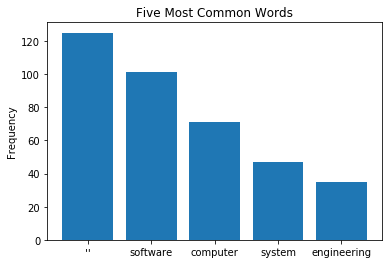

In [925]:
words = [dictionary.get(term[0]) for term in sorted_word_count[:5]]
values = [term[1] for term in sorted_word_count[:5]]

plt.bar(words, values)
plt.title('Five Most Common Words')
plt.ylabel('Frequency')
plt.show();

Alternatively, we can create a bag-of-words model from a single article as follows:

In [926]:
doc = corpus[4]

#sort by word frequency
bow_doc = sorted(doc, key=lambda w: w[1], reverse = True)

#print five most frequent words
for word_id, word_count in bow_doc[:5]:
    print(dictionary.get(word_id), word_count)

'' 50
engineering 32
reverse 24
software 11
ref 10


As we can see, the most frequent words in an article are typically different from the most frequent words of the set of articles. By using larger and larger corpora, we can get a greater picture of the broad 'theme' across all articles. However, if we want specificity, it is better to examine one article. 

What if we have some domain knowledge and expect some shared words between documents? These words would hardly be important, so simple bag-of-words models would not help us as much. This is why we use more complex models, like the term frequency - inverse document frequency model.

#### Term frequency - inverse document frequency

Term frequency - inverse document frequency (tf-idf) allows you to determine the most important words in each document by accounting for the expectation of unimportant shared words between documents. For example, in documents about computer programming, words like 'code' and 'computer' will be very frequent but do not give useful information about the content of the document. This is because we expect words like 'code' to be common. Tf-idf down weights these unimportant shared words by using the following formula:

$ w_{i,j} = tf_{i,j}*log(\frac{N}{df_i}) $ 

- $ w_{i,j} $ = tf-idf weight for token $i$ in document $j$
- $ tf_{i,j} $ = number of token $i$ in document $j$
- $ N $ = total number of documents
- $ df_i $ = number of documents that contain token $i$

The weight will be low if the term does not appear often in the document because the $ tf_{i,j} $ variable will be low. The weight will also be low if the logarithm is close to zero because the internal equation is low. If the total number of documents divided by the number of documents that contain the token is close to one, the logarithm will be close to zero. Therefore, words that occur across many or all documents will have a low tf-idf weight. Words that occur across few documents will have a higher weight. This considers word frequency but accounts for unimportant words - great!

Tf-idf models can be created using Gensim.

In [927]:
#create a new tfidf model
tfidf = TfidfModel(corpus)

#calculate the weights of a single document
tfidf_weights = tfidf[doc]

#sort weights
sorted_tfidf_weights = sorted(tfidf_weights, key=lambda w: w[1], reverse=True)

#print ten most weighted words
for term_id, weight in sorted_tfidf_weights[:10]:
    print(dictionary.get(term_id), weight)

engineering 0.4743429226442076
reverse 0.35575719198315564
3d 0.20829237289045105
product 0.1822558262791447
name= 0.13340894699368336
chikofsky 0.1301827330565319
products 0.1301827330565319
design 0.1185857306610519
competitor 0.10414618644522552
copy 0.10414618644522552


In contrast to the BOW model, the tf-idf model has ranked words like 'computer' and 'software' as less important. This is because they occur so frequently across the articles that they are considered to be uninteresting! Instead, it has highlighted the topics of the text to be words like 'engineering', 'reverse', '3d'. This is really interesting! We would have had no idea that '3d' was a significant topic without our tf-idf model. 

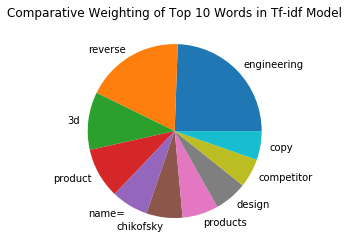

In [928]:
weights = [term[1] for term in sorted_tfidf_weights[:10]]
words = [dictionary.get(term[0]) for term in sorted_tfidf_weights[:10]]

plt.pie(weights, labels=words)
plt.title("Comparative Weighting of Top 10 Words in Tf-idf Model")
plt.plot();

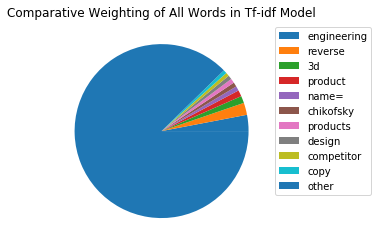

In [929]:
other_weight = sum([term[1] for term in sorted_tfidf_weights[10:]])
weights.append(other_weight)
words.append('other')

plt.pie(weights)
plt.title('Comparative Weighting of All Words in Tf-idf Model')
plt.legend(words, bbox_to_anchor=(1, 1.), loc="upper left")
plt.plot();

As we can see from these plots, while 'engineering' and 'reverse' are the most important words, they are only slightly more important than other words in the text. However, this is expected! If 'reverse' and 'engineering' were more common across the articles, they would be weighted even less!

### Named Entity Recognition

Named entity recognition (NER) is an NLP task used to identify important named entities in a text, such as people, places, organisations, dates, states and works of art. There are NER Libraries, such as the Stanford CoreNLP Library. For convenience, we will use the NER library built into NLTK. 

NER works by associating named entities in text with tags. A news article provided by datacamp will used and NER will be achieved as follows:

- Tokenise article into sentences.
- Tokenise each sentence into words.
- Tag each sentence into parts of speech using nltk.pos_tag.
- 'Chunk' each sentence into NER tags. This creates an NER 'tree' that associates words with tags.

In [930]:
news = '\ufeffThe taxi-hailing company Uber brings into very sharp focus the question of whether corporations can be said to have a moral character. If any human being were to behave with the single-minded and ruthless greed of the company, we would consider them sociopathic. Uber wanted to know as much as possible about the people who use its service, and those who don’t. It has an arrangement with unroll.me, a company which offered a free service for unsubscribing from junk mail, to buy the contacts unroll.me customers had had with rival taxi companies. Even if their email was notionally anonymised, this use of it was not something the users had bargained for. Beyond that, it keeps track of the phones that have been used to summon its services even after the original owner has sold them, attempting this with Apple’s phones even thought it is forbidden by the company.\r\n\r\n\r\nUber has also tweaked its software so that regulatory agencies that the company regarded as hostile would, when they tried to hire a driver, be given false reports about the location of its cars. Uber management booked and then cancelled rides with a rival taxi-hailing company which took their vehicles out of circulation. Uber deny this was the intention. The punishment for this behaviour was negligible. Uber promised not to use this “greyball” software against law enforcement – one wonders what would happen to someone carrying a knife who promised never to stab a policeman with it. Travis Kalanick of Uber got a personal dressing down from Tim Cook, who runs Apple, but the company did not prohibit the use of the app. Too much money was at stake for that.\r\n\r\n\r\nMillions of people around the world value the cheapness and convenience of Uber’s rides too much to care about the lack of drivers’ rights or pay. Many of the users themselves are not much richer than the drivers. The “sharing economy” encourages the insecure and exploited to exploit others equally insecure to the profit of a tiny clique of billionaires. Silicon Valley’s culture seems hostile to humane and democratic values. The outgoing CEO of Yahoo, Marissa Mayer, who is widely judged to have been a failure, is likely to get a $186m payout. This may not be a cause for panic, any more than the previous hero worship should have been a cause for euphoria. Yet there’s an urgent political task to tame these companies, to ensure they are punished when they break the law, that they pay their taxes fairly and that they behave responsibly.'

#tokenize article into sentences
sentences = sent_tokenize(news)
#tokenize each sentence into words
token_sentences = [word_tokenize(sent) for sent in sentences]

#tag each sentence into parts of speech (pos)
pos_sentences = [nltk.pos_tag(sent) for sent in token_sentences]

#create NER chunks
chunked_sentences = nltk.ne_chunk_sents(pos_sentences, binary=True)

#test for stems of tree with 'NE' tags
for sent in chunked_sentences:
    for chunk in sent:
        if hasattr(chunk, "label") and chunk.label() == "NE":
            print(chunk)

(NE Uber/NNP)
(NE Beyond/NN)
(NE Apple/NNP)
(NE Uber/NNP)
(NE Uber/NNP)
(NE Travis/NNP Kalanick/NNP)
(NE Tim/NNP Cook/NNP)
(NE Apple/NNP)
(NE Silicon/NNP Valley/NNP)
(NE CEO/NNP)
(NE Yahoo/NNP)
(NE Marissa/NNP Mayer/NNP)


Every chunk with an 'NE' (named entity) tag is returned. This gives us information about the entities in the news article. We can see that this article is about Silicon Valley businesses and public figures in tech.

Now that we know the basics of NLP, let's apply it!

## Part 2

### Sentiment Analysis of Cryptocurrency News Headlines Before and After the May 2021 'Crypto Crash'

Cryptocurrencies are digital currencies in which transactions are verified and records maintained by a decentralized system using cryptography, rather than by a centralized authority. They are becoming increasingly popular, with online banks like Revolut opening their platforms to laypeople for quick and easy crypto investing. However, on May 21st 2021, the crypto market suddenly crashed. While I will leave speculating why the market crashed to financial analysts, I am interested in how people reacted to the crash. Specifically, I am interested in whether financial news articles reflect market swings. To investigate this, I will compare the sentiment of cryptocurrency headlines before and during the crash using sentiment analysis.

Sentiment analysis is a NLP technique that determines whether natural language data are 'positive', 'negative' or 'neutral' by coding affective words. In the context of financial news, words like 'soar', 'rise' and 'increase' would be positive, while words like 'plummet', 'fall' and 'decrease' would be negative. Non-affective words, such as 'cryptocurrency', 'mine' or 'coin', are coded as neutral.  

I hypothesise that the sentiment of cryptocurrency news headlines before the crash will be more positive and less negative than those after the crash. This is because I believe that news headlines will reflect market swings. To test this hypothesis, I will adapt a Datacamp guided project: 'Extracting Stock Sentiment from News Headlines'. 

#### Sourcing the Data

Upon Datacamp's recommendation, I will use the popular financial news website [Finviz](https://finviz.com/) to extract financial news headline data. Two HTML files of the website were saved. Firstly, the 'Wayback Machine' was used to save the website HTML file before the crash. This provided crypto news data from April 14th - 18th, 2021. Secondly, the website HTML file was saved directly from the Finviz website during the crash. This provided crypto news data from May 17th - 27th. This data will be extracted from the HTML files using web scraping.

#### Web scraping

Web scraping refers to the process of extracting data from websites. This will be done using the urllib, requests and BeautifulSoup modules to extract HTML code and convert it into structured text.

HTML code functions by using different 'tags'. Here's some we need to know for this project:

- 'tr' is the row tag.
- 'td' is the cell tag.

In [946]:
#open and read files
#if you wish to read in, please replace my file directories with your own
april = urllib.request.urlopen("file:///C:/Users/fionn/OneDrive%20-%20National%20University%20of%20Ireland,%20Galway/2nd%20Year/Semester%202/Data%20Science%20Project/crypto_april_2021.html").read()
may = urllib.request.urlopen("file:///C:/Users/fionn/OneDrive%20-%20National%20University%20of%20Ireland,%20Galway/2nd%20Year/Semester%202/Data%20Science%20Project/crypto_may_2021.html").read()

#store the news headlines tables from the code
april_soup = BeautifulSoup(april, "lxml")
april_table = april_soup.find(attrs={"id":"news-table"})

may_soup = BeautifulSoup(may, "lxml")
may_table = may_soup.find(attrs={"id":"news-table"})

We have now converted the HTML code into text, as can be seen below for the April data. It also contains some additional JavaScript from the Wayback machine but we will filter that out!

In [932]:
print(april_soup.prettify())

<!DOCTYPE html>
<html>
 <head>
  <script src="//archive.org/includes/analytics.js?v=cf34f82" type="text/javascript">
  </script>
  <script type="text/javascript">
   window.addEventListener('DOMContentLoaded',function(){var v=archive_analytics.values;v.service='wb';v.server_name='wwwb-app12.us.archive.org';v.server_ms=444;archive_analytics.send_pageview({});});
  </script>
  <script charset="utf-8" src="/_static/js/playback.bundle.js?v=xTFGO54E" type="text/javascript">
  </script>
  <script charset="utf-8" src="/_static/js/wombat.js?v=i68pdzR-" type="text/javascript">
  </script>
  <script type="text/javascript">
   __wm.init("https://web.archive.org/web");
  __wm.wombat("https://finviz.com/quote.ashx?t=Coin","20210418203711","https://web.archive.org/","web","/_static/",
	      "1618778231");
  </script>
  <link href="/_static/css/banner-styles.css?v=omkqRugM" rel="stylesheet" type="text/css"/>
  <link href="/_static/css/iconochive.css?v=qtvMKcIJ" rel="stylesheet" type="text/css"/>
  <

#### Parsing the headline data

Now we will parse the data for all tables into a more comfortable data structure.

In [933]:
#hold the parsed news into a list
parsed_april = []
for x in april_table.findAll('tr'):
    #read the text from the tr (row) tag into text
    text = x.get_text() 
    
    #split the text in the td (cell) tag into a list 
    date_scrape = x.td.text.split()
    
    #if the length of 'date_scrape' is 1, load 'time' with the only element
    #if not, load 'date' with the 1st element and 'time' with the second
    if len(date_scrape) == 1:
        time = date_scrape[0]
    else:
        date = date_scrape[0]
        time = date_scrape[1]
        
    parsed_april.append([date, time, x.a.text])

#repeat for may
parsed_may = []
for x in may_table.findAll('tr'):
    text = x.get_text() 
    date_scrape = x.td.text.split()
    if len(date_scrape) == 1:
        time = date_scrape[0]
    else:
        date = date_scrape[0]
        time = date_scrape[1]
        
    parsed_may.append([date, time, x.a.text])

In [934]:
print(parsed_april[0])
print(parsed_may[0])

['Apr-18-21', '04:12PM', 'Dow Jones Futures Loom, Bitcoin Dives As Stock Market Rally Enters Power Trend; Square, Apple, Tesla In Focus']
['May-27-21', '01:40PM', 'Is Coinbase Stock A Buy Right Now After Surging On Key Analyst Buy Rating?']


We can see that the parsed data for April and May have been stored as two separate lists of lists. This allows us to begin our sentiment analysis.

#### Sentiment Analysis

NLTK provides a package for sentiment analysis called 'Vader'. However, financial analysts have their own lingo that may not be included in the Vader package. To fix this, we will add in some new words and weight them with a score $ s $ between $-100$ and $100$, where $ s = -100 $ is extremely negative and $ s = 100 $ is extremely positive.

Of course, how we weight these words will affect the sentiment score of the headlines. This implies that, while we can reach a consensus on weighting words, sentiment analysis has an element of subjectivity. Of course, generally we can agree that 'happy' is positive and 'sad' is negative, but how positive or negative are they? This becomes even harder to determine with more complex words, like 'soars' or 'falls' in crypto markets. Furthermore, changing the context of words can change their meaning. For example, 'falls' is a positive word when referring to mortality rate of infection. 

While this project does not aim to solve this problem, it is necessary to mention. The 'sentiment' of a word should not be seen as an objective fact but as a subjective choice based on context. Who chooses sentiment scores, and how they are chosen, really matters.

In [935]:
#NLTK VADER for sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer

#new words and sentiment values
new_words = {
    'crushes': 10,
    'beats': 5,
    'misses': -5,
    'trouble': -10,
    'falls': -100,
}
#instantiate the sentiment intensity analyzer with the VADER lexicon
vader = SentimentIntensityAnalyzer()
#update the lexicon with the new words
vader.lexicon.update(new_words)

#### Creating our Sentiment Scores DataFrame

We will now create two dataframes, one for April and one for May. They will have the following headings: data, time, headline, compound, negative, neutral, and positive. Compound refers to the final sentiment score (positive $-$ negative). 

In [936]:
#set column titles
columns = ['date', 'time', 'headline']

#create April dataframe
scored_april = pd.DataFrame(parsed_april, columns=columns)
#iterate through the headlines and get the polarity scores
scores_april = [vader.polarity_scores(headline) for headline in scored_april.headline]
#convert list of dicts to dataframe
scores_april_df = pd.DataFrame(scores_april)
scored_april.columns = columns
#join the dataframes
scored_april = scored_april.join(scores_april_df)
#convert the date column from string to datetime
scored_april['date'] = pd.to_datetime(scored_april.date).dt.date
#convert the time column from string to datetime
scored_april['time'] = pd.to_datetime(scored_april.time).dt.time

#repeat to create May dataframe
scored_may = pd.DataFrame(parsed_may, columns=columns)
scores_may = [vader.polarity_scores(headline) for headline in scored_may.headline]
scores_may_df = pd.DataFrame(scores_may)
scored_may.columns = columns
scored_may = scored_may.join(scores_may_df)
scored_may['date'] = pd.to_datetime(scored_may.date).dt.date
scored_may['time'] = pd.to_datetime(scored_may.time).dt.time

A preview of each dataframe can be found below.

In [937]:
scored_april.head()

,date,time,headline,compound,neg,neu,pos
0,2021-04-18,16:12:00,"Dow Jones Futures Loom, Bitcoin Dives As Stock...",-0.2263,0.101,0.899,0.000
1,2021-04-18,12:22:00,"Barron's Latest Picks And Pans: Amazon, Coinba...",0.1779,0.000,0.866,0.134
2,2021-04-18,11:18:00,Coinbase hangover? Heres why bitcoin may be su...,-0.4767,0.205,0.795,0.000
3,2021-04-18,10:39:00,Coinbase Hangover Rattles Crypto Assets With B...,0.1779,0.000,0.825,0.175
4,2021-04-18,09:44:00,"Bitcoin Plunges, Taking Other Cryptocurrencies...",0.0000,0.000,1.000,0.000


In [938]:
scored_may.head()

,date,time,headline,compound,neg,neu,pos
0,2021-05-27,13:40:00,Is Coinbase Stock A Buy Right Now After Surgin...,0.0000,0.0,1.000,0.000
1,2021-05-26,16:39:00,ZipRecruiter Stock Surges on Debut,0.0000,0.0,1.000,0.000
2,2021-05-26,15:08:00,New FOMO ETF debuts on the market,0.0000,0.0,1.000,0.000
3,2021-05-26,12:14:00,Coinbase CFO maintains bullish Q2 guidance: 'M...,0.0000,0.0,1.000,0.000
4,2021-05-26,11:22:00,Holding On for Dear Life: HODLers Brace for Co...,0.3818,0.0,0.776,0.224


It should also be noted that while we have the same number of headlines for each month, we have more dates available for May than for April. This is because the HTML file for April featured less dates as there were more dates per day to fit on the page. This uptake in featured news stories may have been a consequence of the crash.

In [939]:
print("Number of April headlines:", len(scored_april['date'].unique()))
print("Number of May headlines:", len(scored_may['date'].unique()))
print("Is it true or false that our dataframes for April and May have the same number of headlines?:", len(scored_april) == len(scored_may))
print("Total number of headlines for each month:", len(scored_may))

Number of April headlines: 5
Number of May headlines: 10
Is it true or false that our dataframes for April and May have the same number of headlines?: True
Total number of headlines for each month: 100


Now that we have applied sentiment analysis to our data and stored our months in DataFrames, we can examine our findings through visualisation!

#### Visualising Sentiment Scores

We will start by examining a single day. Let's have a look at May 21st, the day the Crypto Market 'Crashed'. 

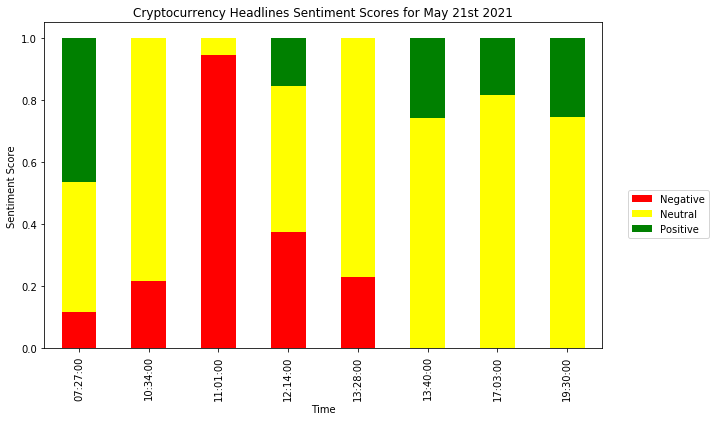

In [940]:
#select may 21st from may dataframe
may_21st = scored_may[scored_may.date == dt.date(2021, 5, 21)]
#drop compound column
may_21st_plot = may_21st.drop(columns = ['compound'])
#order by time
may_21st_plot = may_21st_plot.set_index('time')
may_21st_plot = may_21st_plot.sort_values(by='time',ascending=True)

title = 'Cryptocurrency Headlines Sentiment Scores for May 21st 2021'
colors = ['red', 'yellow', 'green']
legend = ['Negative', 'Neutral', 'Positive']
may_21st_plot.plot.bar(stacked=True, figsize=(10, 6), title = title, color = colors).legend(bbox_to_anchor=(1.2, 0.5))
plt.legend(legend, bbox_to_anchor=(1.2, 0.5))
plt.xlabel('Time')
plt.ylabel('Sentiment Score');

Interesting! It seems like the headline at 11:01am was very negative! Let's take a look at what that headline says.

In [941]:
may_21st[may_21st.time == dt.time(11, 1, 0 ,0)]

,date,time,headline,compound,neg,neu,pos
43,2021-05-21,11:01:00,Bitcoin falls again as China reiterates crackdown,-0.9993,0.944,0.056,0.0


Interesting! The China Crackdown is speculated to be a reason why the market crashed. It is clear why our Sentiment Analyser gave this a negative weighting. Words like 'falls' and 'crackdown' are considered negative in a financial context. 

Now, let's look at the bigger picture. We will visualise the sentiment over the periods of April and May to see if we can eyeball any significant differences. First, we have to find the average sentiment per day for each day of the month we have data for.

In [942]:
#takes average scores per day for April
avg_april = scored_april.groupby('date').mean()
avg_april = avg_april.drop(columns = ['compound'])

#takes average scores per day for May
avg_may = scored_may.groupby('date').mean()
avg_may = avg_may.drop(columns = ['compound'])

In [949]:
#new dataframe with average daily scores
avg_april.head()

,neg,pos
date,,
2021-04-14,0.098333,0.094533
2021-04-15,0.039886,0.092318
2021-04-16,0.040321,0.140643
2021-04-17,0.120000,0.074167
2021-04-18,0.043714,0.086429


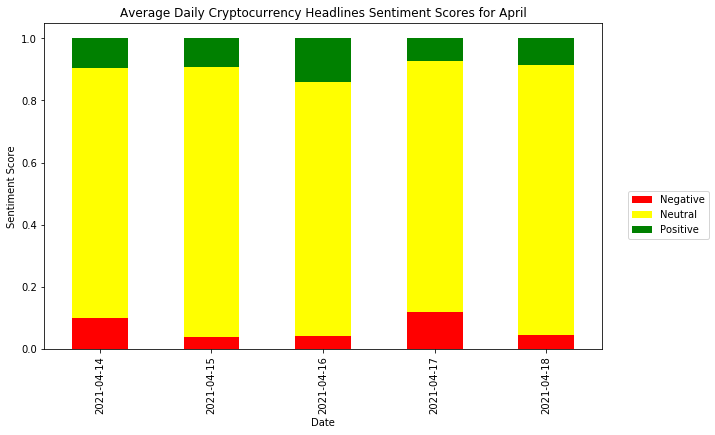

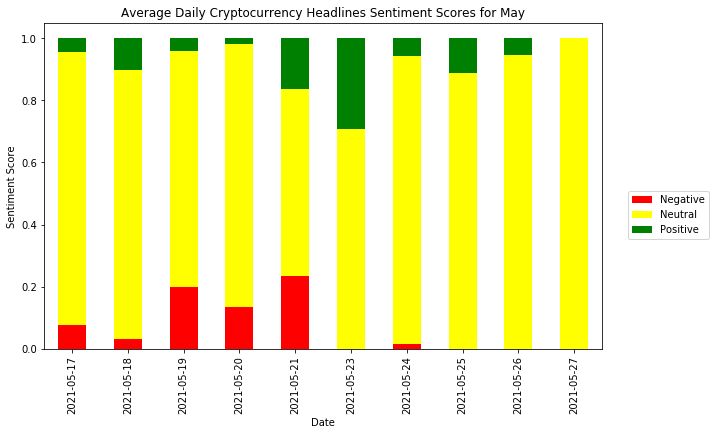

In [943]:
#plot for April
title = 'Average Daily Cryptocurrency Headlines Sentiment Scores for April'
avg_april.plot.bar(stacked=True, figsize=(10, 6), title = title, color = colors).legend(bbox_to_anchor=(1.2, 0.5))
plt.legend(legend, bbox_to_anchor=(1.2, 0.5))
plt.xlabel('Date')
plt.ylabel('Sentiment Score');

#plot for May
title = 'Average Daily Cryptocurrency Headlines Sentiment Scores for May'
avg_may.plot.bar(stacked=True, figsize=(10, 6), title = title, color = colors).legend(bbox_to_anchor=(1.2, 0.5))
plt.legend(legend, bbox_to_anchor=(1.2, 0.5))
plt.xlabel('Date')
plt.ylabel('Sentiment Score');

It seems like there are more negative headlines in May, as expected, but it's hard to tell with the neutral headlines. Let's remove them and take a closer look.

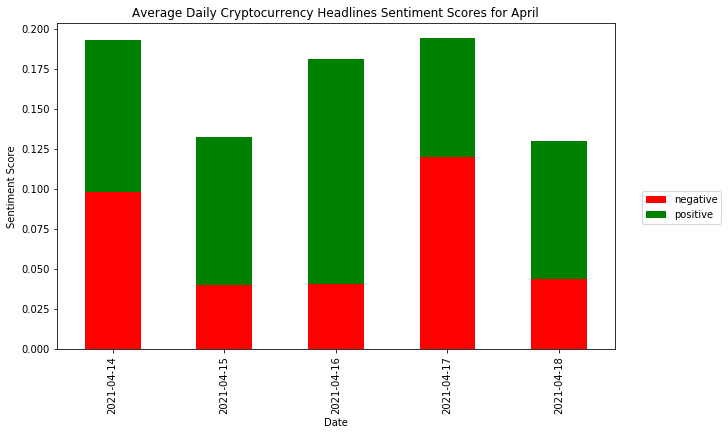

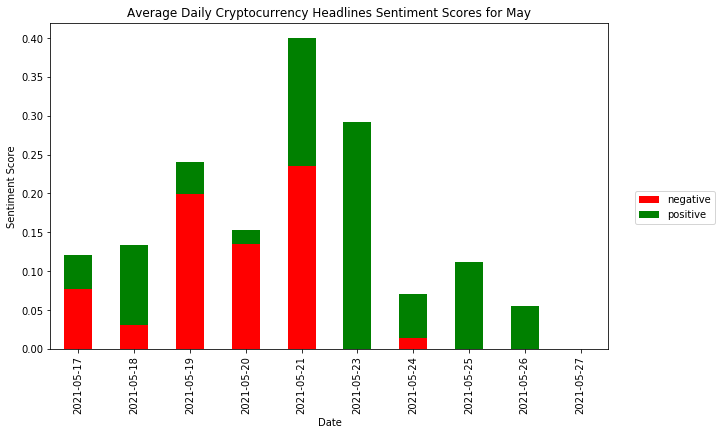

In [944]:
avg_april = avg_april.drop(columns = ['neu'])
avg_may = avg_may.drop(columns = ['neu'])
colors = ['red', 'green']
legend = ['negative', 'positive']

#plot for April
title = 'Average Daily Cryptocurrency Headlines Sentiment Scores for April'
avg_april.plot.bar(stacked=True, figsize=(10, 6), title = title, color = colors).legend(bbox_to_anchor=(1.2, 0.5))
plt.legend(legend, bbox_to_anchor=(1.2, 0.5))
plt.xlabel('Date')
plt.ylabel('Sentiment Score');

#plot for May
title = 'Average Daily Cryptocurrency Headlines Sentiment Scores for May'
avg_may.plot.bar(stacked=True, figsize=(10, 6), title = title, color = colors).legend(bbox_to_anchor=(1.2, 0.5))
plt.legend(legend, bbox_to_anchor=(1.2, 0.5))
plt.xlabel('Date')
plt.ylabel('Sentiment Score');

Much clearer! It seems like there are is more negative sentiment in the May headlines. However, these are nearly all from before the crash! This is the opposite result to what was hypothesised.

## Conclusion

There are many possible reasons for the results we have found:

- News headlines may have been more negative leading up to the crash in its anticipation.
- We do not have enough data to approximate the 'true' sentiment of the news headlines. 
- The large amount of neutral words may indicate that we have not specified our lexicon precisely enough to capture financial sentiment.
- Sentiment of news headlines is not associated with market swings. 

For a deeper analysis, several steps could be taken:

- Develop a better sentiment analyser using financial news corpora. 
- Draw from a larger sample.
- Perform statistical tests, including hypothesis tests. 
- Perform tests of association between market swings and news headline sentiments. 

If a thorough investigation reveals an association, it is possible that news headlines may hold predictive validity over market swings. This is only true if news has an impact on markets, which is possible. However, it may be that news is purely a reaction to the market and has no impact on market swings. 

In conclusion, natural language processing is a unique and powerful data analysis tool. It has applications, including chatbots, sentiment analysis and translation software. This project aimed to explain natural language processing concepts and skills, before applying these to the sentiment analysis of financial news before and after the May 2021 Cryptocurrency Crash. Thank you for reading!